# Bangladeshi Traffic Sign Classification — Exploration & Training Notebook

This notebook walks through the same pipeline as the `src/` scripts, but interactively — useful for exploring the real dataset, visualizing class distribution, and sanity-checking augmentation before running full training with `python -m src.train`.

**Before running this notebook:** download a real Bangladeshi traffic sign dataset and place it at `data/raw/<ClassName>/<image files>` (see README.md for dataset sources).

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

from src import config
from src.data_preprocessing import verify_raw_dataset, split_dataset
from src.data_augmentation import get_datasets, get_augmentation_layer
import matplotlib.pyplot as plt
import numpy as np

## 1. Verify the real dataset and check class balance

Found 27 class folders in data/raw/: ['Crossroads', 'Emergency_Stopping', 'Emergency_Stopping_250m', 'Give_Way', 'Height_Limit_5.7m', 'Junction_Ahead', 'Mosque_Ahead', 'No_Overtaking', 'No_Pedestrians', 'No_Vehicle_Entry', 'Pedestrians_Crossing', 'Petrol_Pump_Ahead', 'School_Ahead', 'Sharp_Left_Turn', 'Sharp_Right_Turn', 'Side_Road_On_Left', 'Side_Road_On_Right', 'Speed_Breaker', 'Speed_Limit_20_km', 'Speed_Limit_40Km', 'Speed_Limit_80Km', 'Tolls_1_km_Ahead', 'Tolls_Ahead', 'Traffic_Merges_From_Left', 'Truck_Lane', 'U_Turn', 'Underpass_Ahead']
  - Crossroads: 635 real images
  - Emergency_Stopping: 616 real images
  - Emergency_Stopping_250m: 175 real images
  - Give_Way: 178 real images
  - Height_Limit_5.7m: 950 real images
  - Junction_Ahead: 48 real images
  - Mosque_Ahead: 587 real images
  - No_Overtaking: 536 real images
  - No_Pedestrians: 81 real images
  - No_Vehicle_Entry: 182 real images
  - Pedestrians_Crossing: 631 real images
  - Petrol_Pump_Ahead: 617 real images
  - Sc

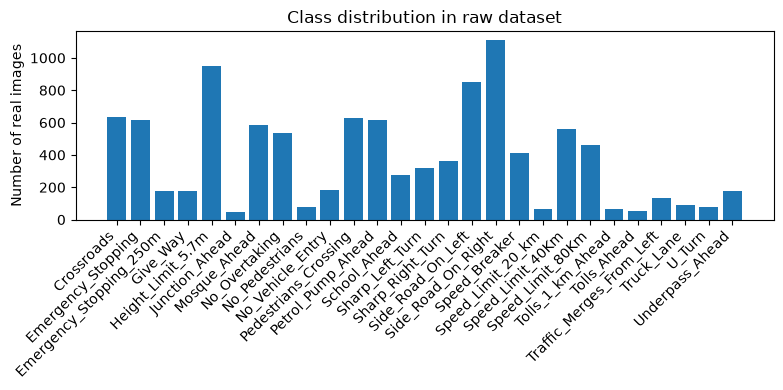

{'Crossroads': 635, 'Emergency_Stopping': 616, 'Emergency_Stopping_250m': 175, 'Give_Way': 178, 'Height_Limit_5.7m': 950, 'Junction_Ahead': 48, 'Mosque_Ahead': 587, 'No_Overtaking': 536, 'No_Pedestrians': 81, 'No_Vehicle_Entry': 182, 'Pedestrians_Crossing': 631, 'Petrol_Pump_Ahead': 617, 'School_Ahead': 276, 'Sharp_Left_Turn': 322, 'Sharp_Right_Turn': 360, 'Side_Road_On_Left': 853, 'Side_Road_On_Right': 1109, 'Speed_Breaker': 411, 'Speed_Limit_20_km': 66, 'Speed_Limit_40Km': 561, 'Speed_Limit_80Km': 463, 'Tolls_1_km_Ahead': 66, 'Tolls_Ahead': 56, 'Traffic_Merges_From_Left': 135, 'Truck_Lane': 91, 'U_Turn': 75, 'Underpass_Ahead': 180}


In [2]:
classes = verify_raw_dataset()
counts = {c: len(os.listdir(os.path.join(config.RAW_DATA_DIR, c))) for c in classes}

plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of real images')
plt.title('Class distribution in raw dataset')
plt.tight_layout()
plt.show()
print(counts)

## 2. Split into train/val/test (real images only, no synthetic data)

In [3]:
summary = split_dataset()
summary

Found 27 class folders in data/raw/: ['Crossroads', 'Emergency_Stopping', 'Emergency_Stopping_250m', 'Give_Way', 'Height_Limit_5.7m', 'Junction_Ahead', 'Mosque_Ahead', 'No_Overtaking', 'No_Pedestrians', 'No_Vehicle_Entry', 'Pedestrians_Crossing', 'Petrol_Pump_Ahead', 'School_Ahead', 'Sharp_Left_Turn', 'Sharp_Right_Turn', 'Side_Road_On_Left', 'Side_Road_On_Right', 'Speed_Breaker', 'Speed_Limit_20_km', 'Speed_Limit_40Km', 'Speed_Limit_80Km', 'Tolls_1_km_Ahead', 'Tolls_Ahead', 'Traffic_Merges_From_Left', 'Truck_Lane', 'U_Turn', 'Underpass_Ahead']
  - Crossroads: 635 real images
  - Emergency_Stopping: 616 real images
  - Emergency_Stopping_250m: 175 real images
  - Give_Way: 178 real images
  - Height_Limit_5.7m: 950 real images
  - Junction_Ahead: 48 real images
  - Mosque_Ahead: 587 real images
  - No_Overtaking: 536 real images
  - No_Pedestrians: 81 real images
  - No_Vehicle_Entry: 182 real images
  - Pedestrians_Crossing: 631 real images
  - Petrol_Pump_Ahead: 617 real images
  - Sc

{'Crossroads': {'train': 444, 'val': 95, 'test': 96},
 'Emergency_Stopping': {'train': 431, 'val': 92, 'test': 93},
 'Emergency_Stopping_250m': {'train': 122, 'val': 26, 'test': 27},
 'Give_Way': {'train': 124, 'val': 26, 'test': 28},
 'Height_Limit_5.7m': {'train': 665, 'val': 142, 'test': 143},
 'Junction_Ahead': {'train': 33, 'val': 7, 'test': 8},
 'Mosque_Ahead': {'train': 410, 'val': 88, 'test': 89},
 'No_Overtaking': {'train': 375, 'val': 80, 'test': 81},
 'No_Pedestrians': {'train': 56, 'val': 12, 'test': 13},
 'No_Vehicle_Entry': {'train': 127, 'val': 27, 'test': 28},
 'Pedestrians_Crossing': {'train': 441, 'val': 94, 'test': 96},
 'Petrol_Pump_Ahead': {'train': 431, 'val': 92, 'test': 94},
 'School_Ahead': {'train': 193, 'val': 41, 'test': 42},
 'Sharp_Left_Turn': {'train': 225, 'val': 48, 'test': 49},
 'Sharp_Right_Turn': {'train': 251, 'val': 54, 'test': 55},
 'Side_Road_On_Left': {'train': 597, 'val': 127, 'test': 129},
 'Side_Road_On_Right': {'train': 776, 'val': 166, 'tes

## 3. Preview a few real training images before/after augmentation

Found 7169 files belonging to 27 classes.
Found 1528 files belonging to 27 classes.
Found 1563 files belonging to 27 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10.851952..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..221.80582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [28.444214..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [39.798325..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [17.339462..255.0].


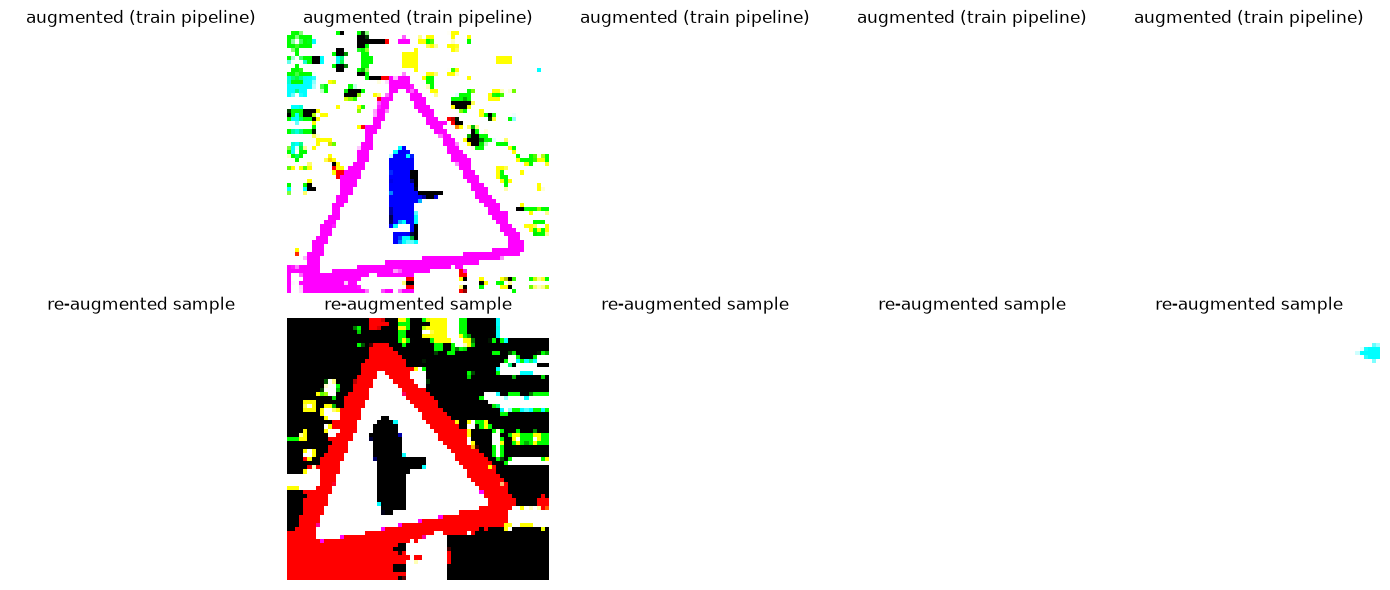

In [4]:
train_ds, val_ds, test_ds = get_datasets()
aug_layer = get_augmentation_layer()

images, labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    axes[0, i].imshow(images[i].numpy())
    axes[0, i].set_title('augmented (train pipeline)')
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(aug_layer(images[i:i+1], training=True)[0].numpy(), 0, 1))
    axes[1, i].set_title('re-augmented sample')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 4. Train from the notebook (optional — or just run `python -m src.train` from a terminal)

In [5]:
from src.train import main as train_main
train_main(['custom_cnn', 'mobilenetv2', 'efficientnetb0'])

Loading real train/val/test datasets from data/processed/ ...
Found 7169 files belonging to 27 classes.
Found 1528 files belonging to 27 classes.
Found 1563 files belonging to 27 classes.
Computed class weights (to counter class imbalance): {0: 0.5980146813480147, 1: 0.6160522471427344, 2: 2.176381299332119, 3: 2.141278375149343, 4: 0.39927596769702034, 5: 8.04601571268238, 6: 0.6476061427280939, 7: 0.7080493827160493, 8: 4.741402116402116, 9: 2.0906969962088073, 10: 0.6020828084320148, 11: 0.6160522471427344, 12: 1.3757436192669352, 13: 1.180082304526749, 14: 1.05784270326103, 15: 0.44475463738445314, 16: 0.3421630393279878, 17: 0.9251516324687057, 18: 5.772141706924316, 19: 0.6773431594860166, 20: 0.8195016003657979, 21: 5.772141706924316, 22: 6.8081671415004745, 23: 2.8246650906225375, 24: 4.214579659024103, 25: 5.106125356125356, 26: 2.1241481481481483}

######################################################################
# Training: custom_cnn
###################################

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_last (Conv2D)            │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 308,795 (1.18 MB)

 Trainable params: 307,899 (1.17 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,217,022 (16.09 MB)

 Trainable params: 167,451 (654.11 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5114 - loss: 1.4973
Epoch 1: val_accuracy improved from None to 0.78665, saving model to d:\bd-traffic-sign-classifier\models\efficientnetb0_best.keras

Epoch 1: finished saving model to d:\bd-traffic-sign-classifier\models\efficientnetb0_best.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.5114 - loss: 1.4973 - val_accuracy: 0.7866 - val_loss: 0.7670 - learning_rate: 0.0010
Epoch 2/50
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7160 - loss: 0.7765
Epoch 2: val_accuracy improved from 0.78665 to 0.88678, saving model to d:\bd-traffic-sign-classifier\models\efficientnetb0_best.keras

Epoch 2: finished saving model to d:\bd-traffic-sign-classifier\models\efficientnetb0_best.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7160 - loss: 0.7764 - val_accuracy: 0.8868 - val_loss: 0.4661 - learning_rate: 0.0010
Epoch 3/50
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7697 - loss

## 5. Evaluate the best model

In [6]:
from src.evaluate import evaluate_model
metrics = evaluate_model('best_model')
metrics

Loading model from d:\bd-traffic-sign-classifier\models\best_model.keras
Found 7169 files belonging to 27 classes.
Found 1528 files belonging to 27 classes.
Found 1563 files belonging to 27 classes.

Evaluation results for: best_model
Accuracy : 0.9955
Precision: 0.9961 (weighted)
Recall   : 0.9955 (weighted)
F1-score : 0.9957 (weighted)

Classification report:
                           precision    recall  f1-score   support

              Crossroads       1.00      1.00      1.00        96
      Emergency_Stopping       1.00      1.00      1.00        93
 Emergency_Stopping_250m       1.00      1.00      1.00        27
                Give_Way       1.00      0.96      0.98        28
       Height_Limit_5.7m       0.99      1.00      1.00       143
          Junction_Ahead       0.73      1.00      0.84         8
            Mosque_Ahead       1.00      1.00      1.00        89
           No_Overtaking       1.00      1.00      1.00        81
          No_Pedestrians       1.00     

{'model': 'best_model',
 'accuracy': 0.9955214331413947,
 'precision_weighted': 0.9960828318388382,
 'recall_weighted': 0.9955214331413947,
 'f1_weighted': 0.9956640817026664}